In [8]:
import pandas as pd
df = pd.read_csv("retail_sales_cleaned.csv", sep=";")
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,City,Category,Product,Quantity,Sales,Cost,Profit,Payment_Method,Profit_cek,Check
0,ORD0312,2026-01-01 00:00:00,C191,Budi,Kulon Progo,Electronics,Keyboard,4,540000,396500,143500,E-Wallet,143500,OK
1,ORD0363,2026-01-01 00:00:00,C126,Gita,Yogyakarta,Office Supplies,Pen,1,8000,6900,1100,E-Wallet,1100,OK
2,ORD0175,2026-01-01 00:00:00,C059,Fajar,Yogyakarta,Accessories,Flash Drive,1,85000,74000,11000,E-Wallet,11000,OK
3,ORD0912,2026-01-01 00:00:00,C029,Eka,Gunungkidul,Furniture,Desk,1,950000,696200,253800,E-Wallet,253800,OK
4,ORD0196,2026-01-02 00:00:00,C085,Gita,Yogyakarta,Furniture,Bookshelf,1,665000,525700,139300,Transfer,139300,OK


In [11]:
df = df.drop(columns=["Profit_cek", "Check"])
print(df.columns.tolist())
df.info()

['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'City', 'Category', 'Product', 'Quantity', 'Sales', 'Cost', 'Profit', 'Payment_Method']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Order_ID        1000 non-null   object
 1   Order_Date      1000 non-null   object
 2   Customer_ID     1000 non-null   object
 3   Customer_Name   1000 non-null   object
 4   City            1000 non-null   object
 5   Category        1000 non-null   object
 6   Product         1000 non-null   object
 7   Quantity        1000 non-null   int64 
 8   Sales           1000 non-null   int64 
 9   Cost            1000 non-null   int64 
 10  Profit          1000 non-null   int64 
 11  Payment_Method  1000 non-null   object
dtypes: int64(4), object(8)
memory usage: 93.9+ KB


In [12]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
print(df.dtypes)

Order_ID                  object
Order_Date        datetime64[ns]
Customer_ID               object
Customer_Name             object
City                      object
Category                  object
Product                   object
Quantity                   int64
Sales                      int64
Cost                       int64
Profit                     int64
Payment_Method            object
dtype: object


In [13]:
df[["Quantity", "Sales", "Cost", "Profit"]].describe()

,Quantity,Sales,Cost,Profit
count,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03
mean,1.913000,3.313277e+05,2.622022e+05,6.912550e+04
std,1.124587,7.189244e+05,5.749514e+05,1.493563e+05
min,1.000000,6.800000e+03,5.000000e+03,9.000000e+02
25%,1.000000,3.600000e+04,2.907500e+04,7.100000e+03
50%,2.000000,9.700000e+04,7.655000e+04,2.200000e+04
75%,2.000000,2.800000e+05,2.245250e+05,6.057500e+04
max,5.000000,8.800000e+06,7.360800e+06,2.105100e+06


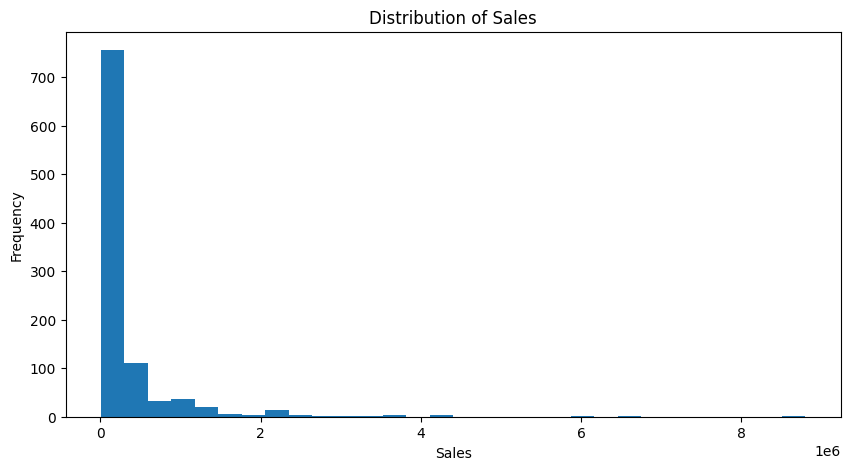

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["Sales"], bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

In [15]:
df.sort_values("Sales", ascending=False)[
    ["Order_ID", "Product", "Category", "Quantity", "Sales", "Profit"]
].head(10)

,Order_ID,Product,Category,Quantity,Sales,Profit
315,ORD0340,Monitor,Electronics,4,8800000,1439200
306,ORD0569,Monitor,Electronics,4,8800000,2105100
528,ORD0779,Monitor,Electronics,3,6600000,1323600
931,ORD0209,Monitor,Electronics,3,5940000,1052300
869,ORD0002,Monitor,Electronics,2,4400000,1099800
618,ORD0250,Monitor,Electronics,2,4400000,795900
466,ORD0537,Monitor,Electronics,2,4400000,584400
928,ORD0158,Monitor,Electronics,2,4180000,1030100
164,ORD0871,Desk,Furniture,4,3610000,603200
74,ORD0620,Office Chair,Furniture,3,3600000,487100


In [16]:
product_profit = (
    df.groupby("Product")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

product_profit.head(10)

,Profit
Product,
Monitor,13502800
Drawer,8412300
Office Chair,6685600
Webcam,5752100
Bookshelf,4576800
Desk,4360400
Backpack,4150300
Lamp,3257300
Power Bank,3171300


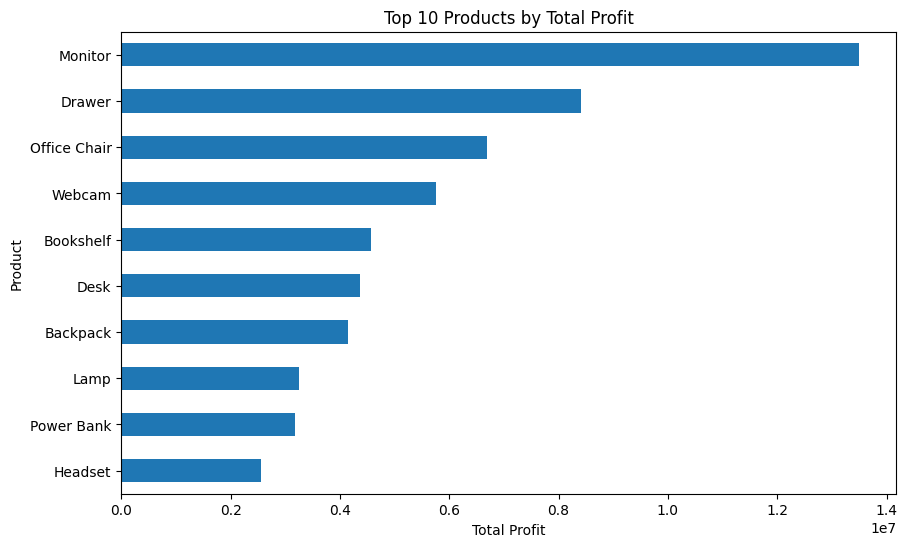

In [17]:
import matplotlib.pyplot as plt

product_profit.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Total Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product")
plt.show()

In [18]:
monthly_sales = (
    df.groupby(df["Order_Date"].dt.to_period("M"))["Sales"]
    .sum()
)

monthly_sales

,Sales
Order_Date,
2026-01,50576500
2026-02,44309400
2026-03,68045900
2026-04,57772400
2026-05,50569300
2026-06,60054200


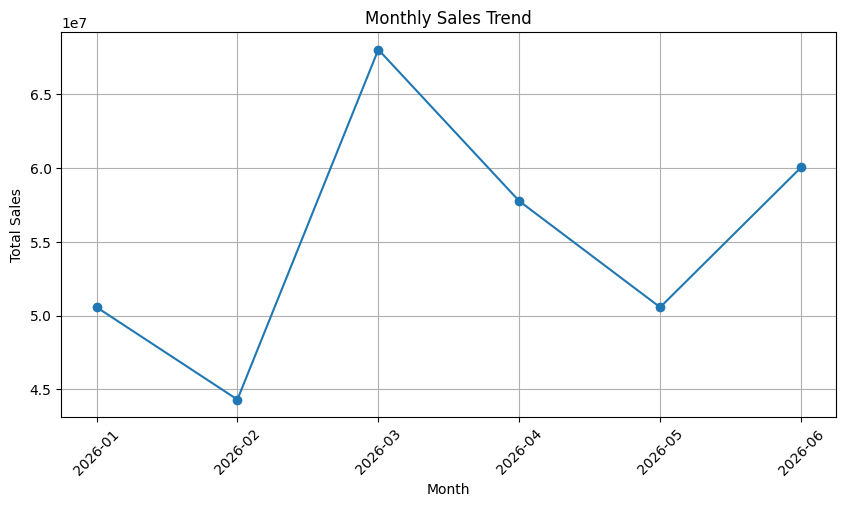

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [20]:
city_sales = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

city_sales

,Sales
City,
Yogyakarta,101211700
Sleman,86087400
Gunungkidul,60252100
Bantul,43268200
Kulon Progo,40508300


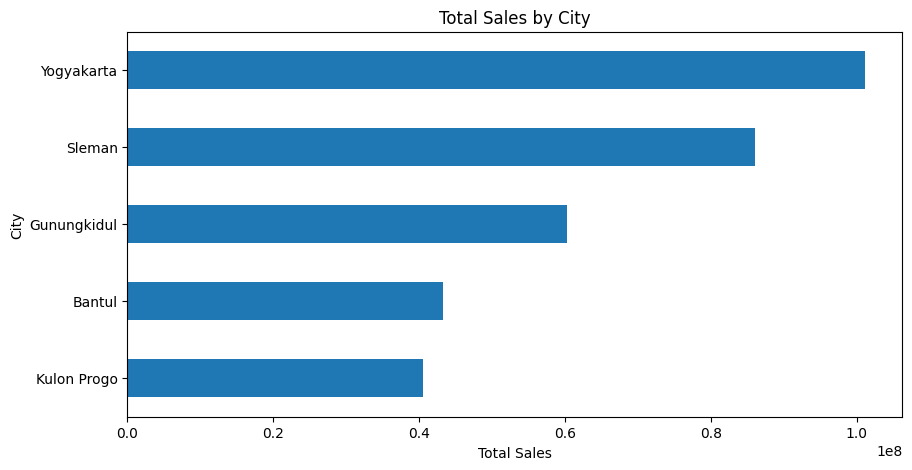

In [22]:
plt.figure(figsize=(10, 5))

city_sales.sort_values().plot(kind="barh")

plt.title("Total Sales by City")
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.show()

In [23]:
city_profit = (
    df.groupby("City")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

city_profit

,Profit
City,
Yogyakarta,21222200
Sleman,17893200
Gunungkidul,12376600
Bantul,8936500
Kulon Progo,8697000


In [24]:
city_analysis = df.groupby("City").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

city_analysis["Profit_Margin"] = (
    city_analysis["Profit"] / city_analysis["Sales"] * 100
)

city_analysis.sort_values("Profit_Margin", ascending=False)

,Sales,Profit,Profit_Margin
City,,,
Kulon Progo,40508300,8697000,21.469674
Yogyakarta,101211700,21222200,20.968129
Sleman,86087400,17893200,20.784923
Bantul,43268200,8936500,20.653736
Gunungkidul,60252100,12376600,20.541359


In [25]:
city_analysis = df.groupby("City").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

city_analysis["Profit_Margin"] = (
    city_analysis["Profit"] / city_analysis["Sales"] * 100
)

city_analysis.sort_values("Profit_Margin", ascending=False)

,Sales,Profit,Profit_Margin
City,,,
Kulon Progo,40508300,8697000,21.469674
Yogyakarta,101211700,21222200,20.968129
Sleman,86087400,17893200,20.784923
Bantul,43268200,8936500,20.653736
Gunungkidul,60252100,12376600,20.541359


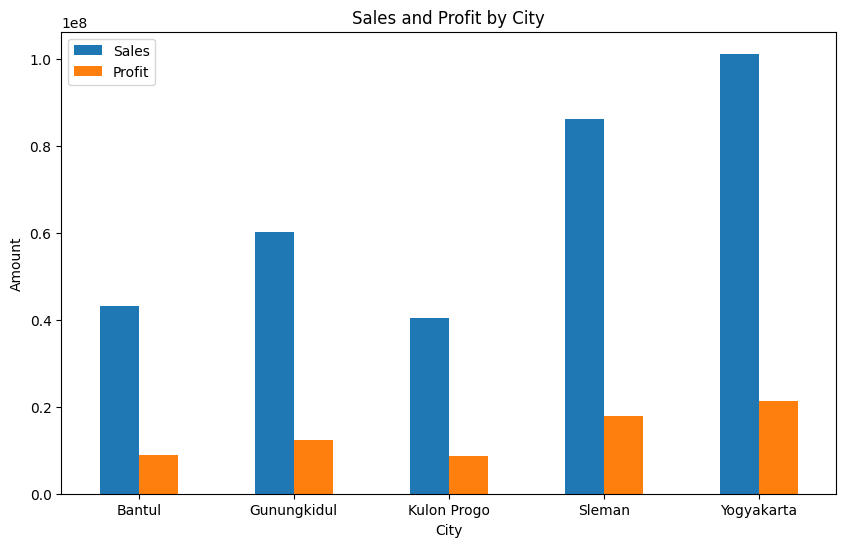

In [26]:
city_analysis[["Sales", "Profit"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by City")
plt.xlabel("City")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend()
plt.show()